In [3]:
import sounddevice as sd
from scipy.io.wavfile import write

fs = 16000  # sample rate
seconds = 5

print("Recording...")
audio = sd.rec(int(seconds * fs), samplerate=fs, channels=1)
sd.wait()

write("voice.wav", fs, audio)


Recording...


In [47]:
import numpy as np
from scipy.io.wavfile import read, write

fs, x = read("voice.wav")
x = x.astype(float)

delay = int(0.2 * fs)  # 200ms delay
alpha = 0.4            # độ mạnh echo

echo = np.zeros_like(x)
echo[delay:] = x[:-delay]

mic = x + alpha * echo

write("mic.wav", fs, mic.astype(np.int16))


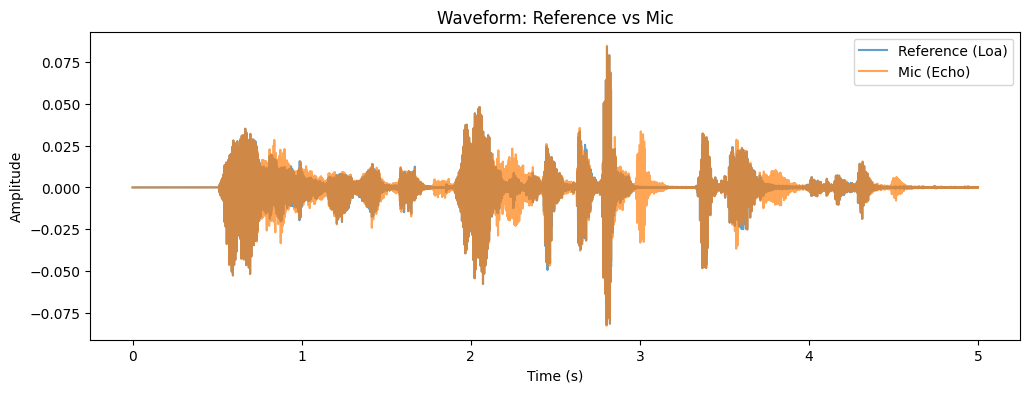

In [53]:
import matplotlib.pyplot as plt

t = np.linspace(0, len(x)/fs, len(x))

plt.figure(figsize=(12,4))
plt.plot(t, x, label="Reference (Loa)", alpha=0.7)
plt.plot(t, mic, label="Mic (Echo)", alpha=0.7)
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Waveform: Reference vs Mic")
plt.show()


In [50]:
print("Phát tín hiệu gốc (x)...")
sd.play(x, fs)
sd.wait()

Phát tín hiệu gốc (x)...


In [52]:
print("Phát tín hiệu mic có echo (mic)...")
sd.play(mic, fs)
sd.wait()

Phát tín hiệu mic có echo (mic)...


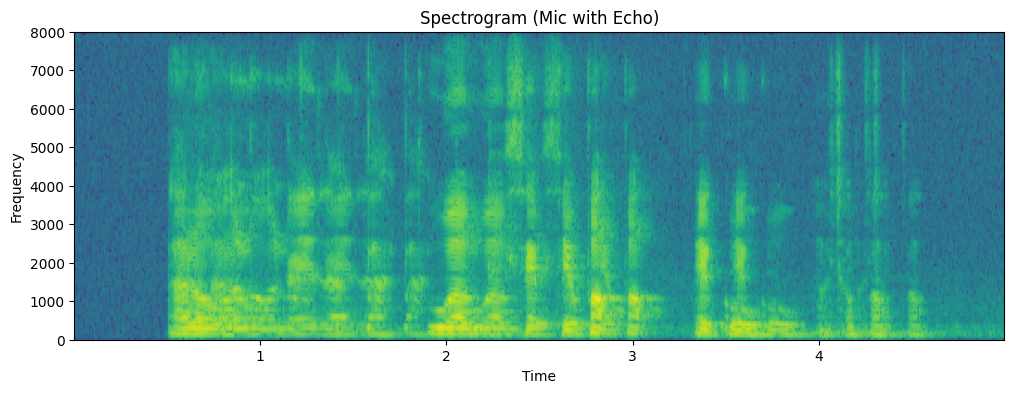

In [54]:
plt.figure(figsize=(12,4))
mic_for_spec = mic if mic.ndim == 1 else mic[:, 0]
plt.specgram(mic_for_spec, Fs=fs)
plt.title("Spectrogram (Mic with Echo)")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.show()
